100%|██████████| 24.3k/24.3k [00:00<00:00, 5.14MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ziya07/student-mental-health-and-resilience-dataset/versions/1

Dataset Loaded Successfully!
File: mental_health_dataset.csv

================ FIRST 5 ROWS ================
   Student_ID  Age  Gender   GPA  Stress_Level  Anxiety_Score  \
0           1   23   Other  2.52             5             20   
1           2   19    Male  2.74             5              3   
2           3   21  Female  3.53             5             11   
3           4   18    Male  2.04             4             15   
4           5   19   Other  2.87             1              2   

   Depression_Score                                  Daily_Reflections  \
0                 6  Onto foreign do environmental anyone every nea...   
1                 7  Party but others visit admit industry country ...   
2                24  Religious sure wait do chance decade according...   
3                14            A task effect entire coach join se

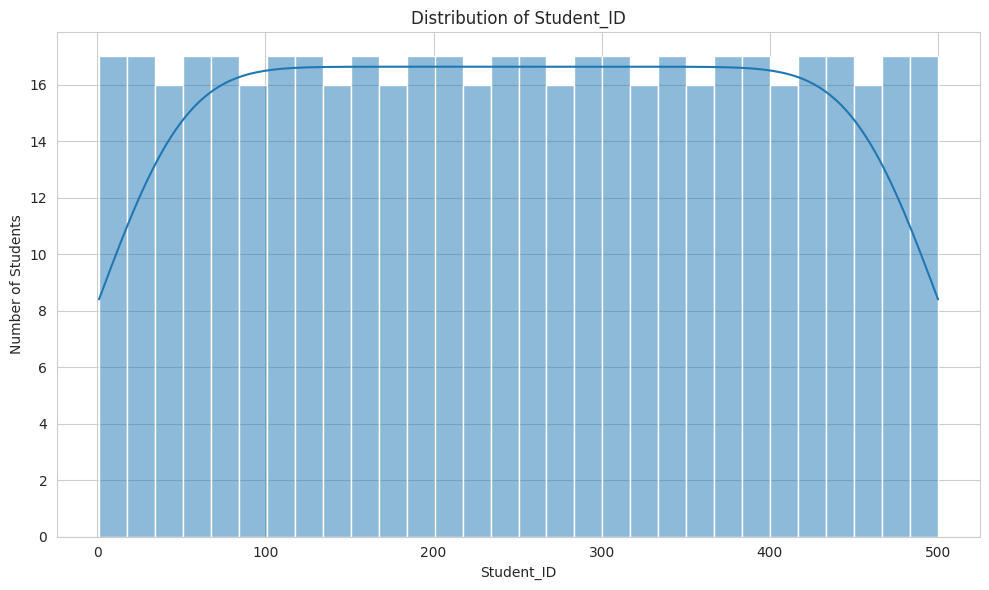

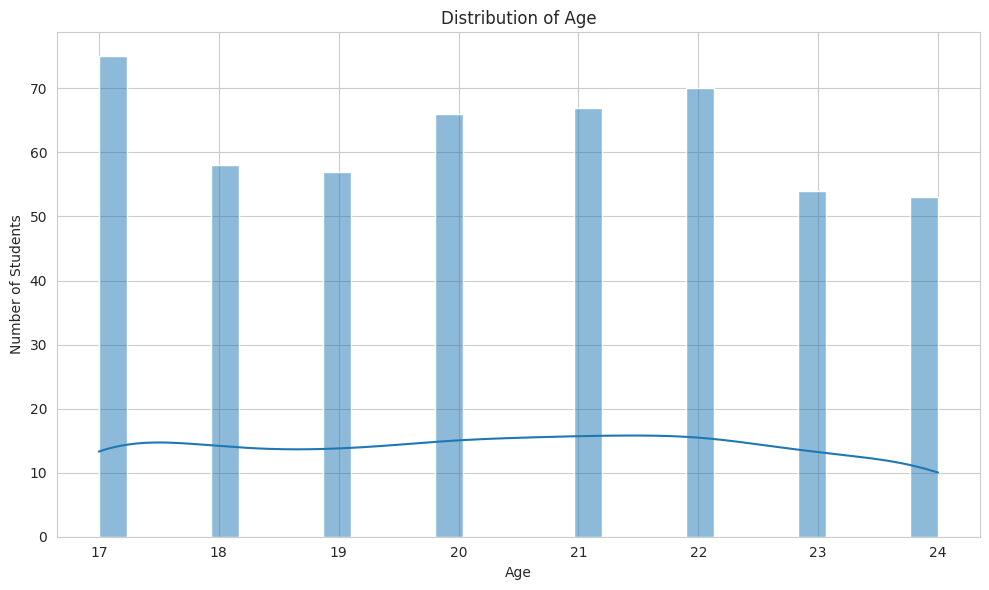

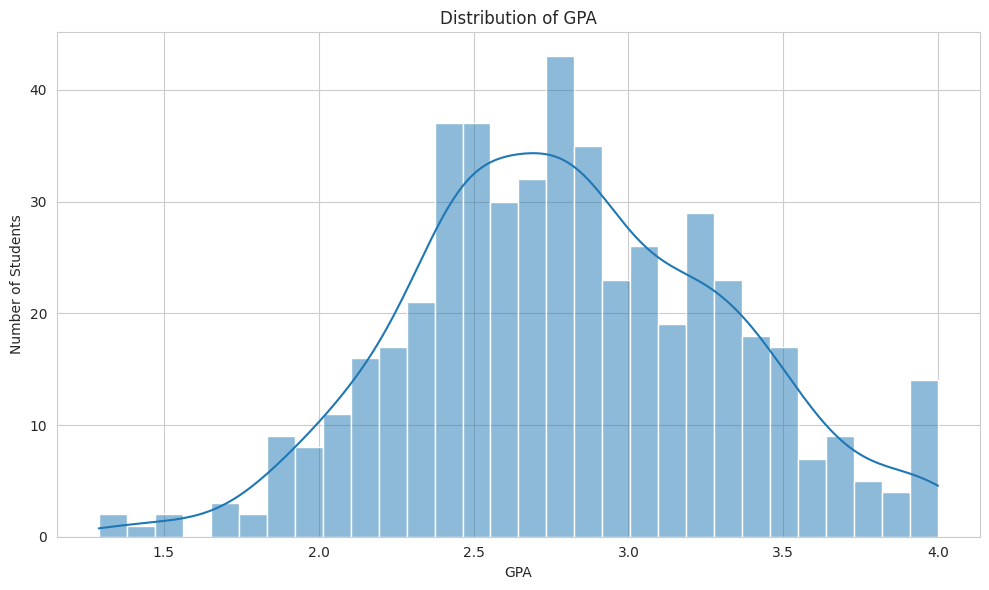

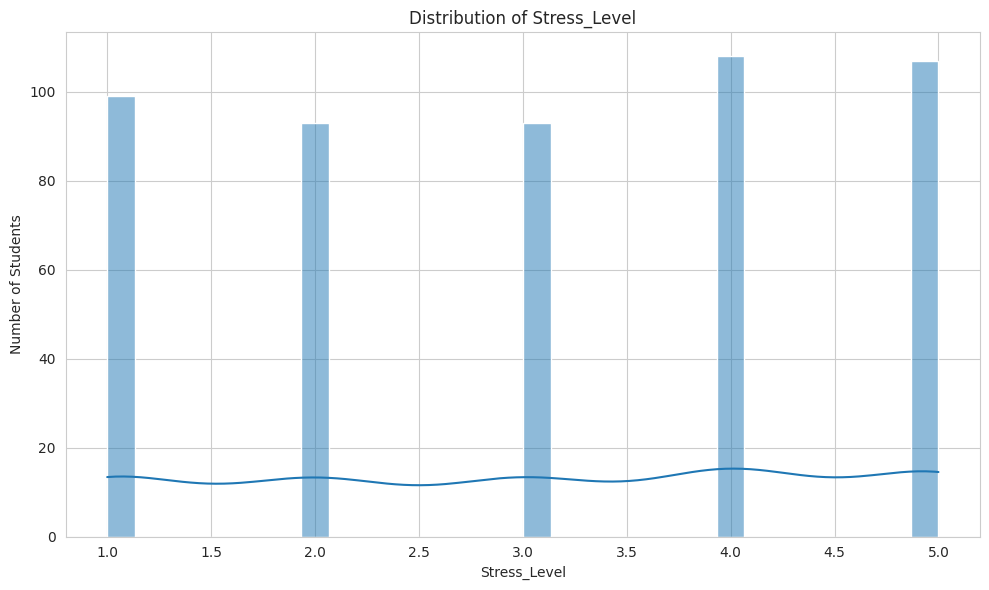

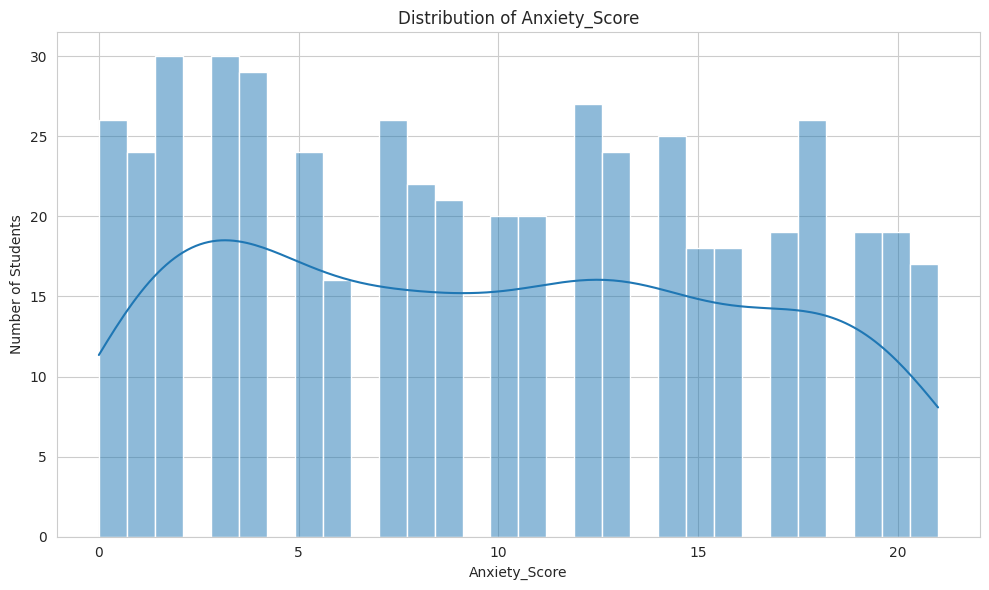

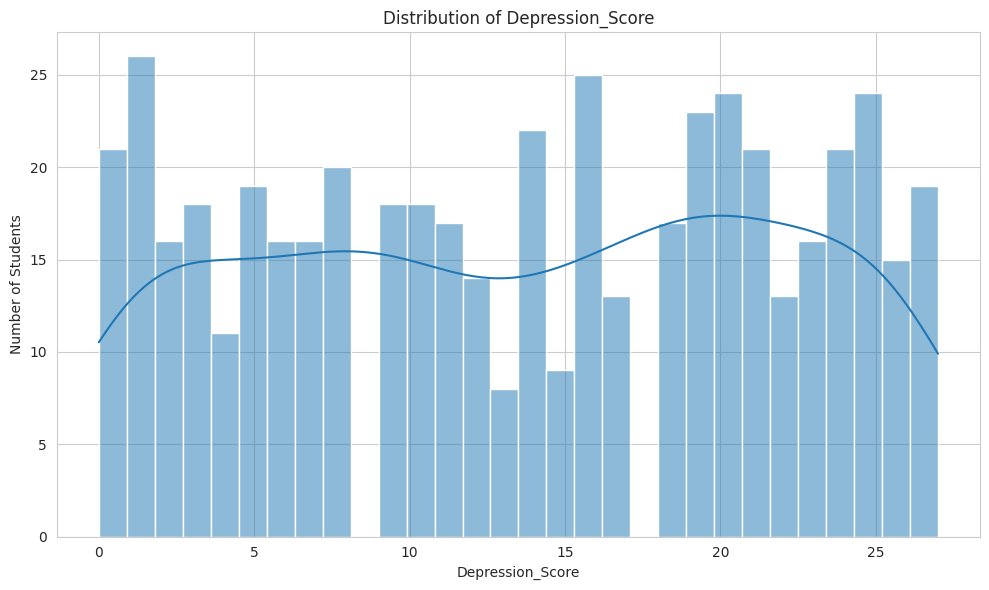

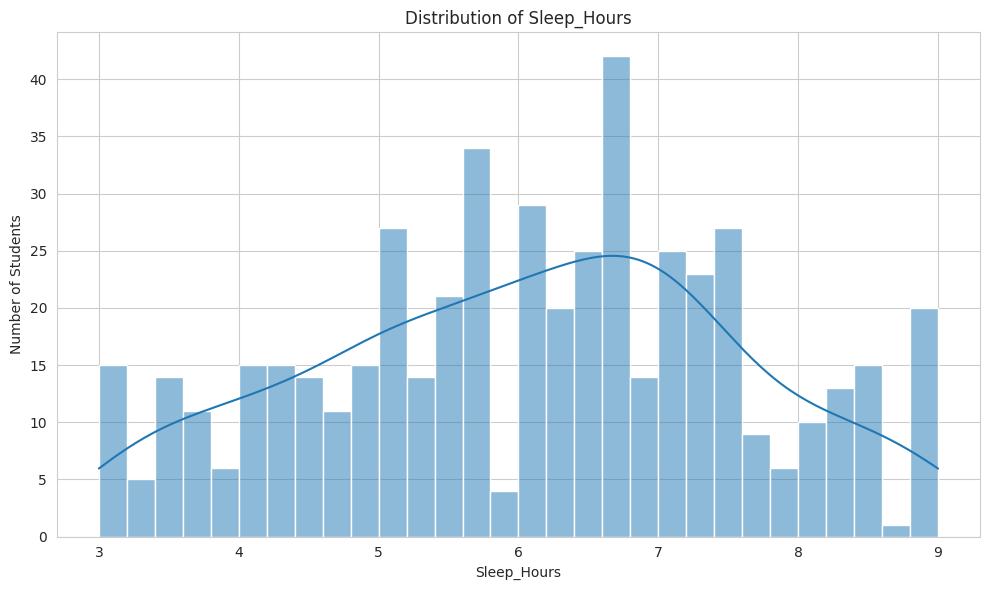

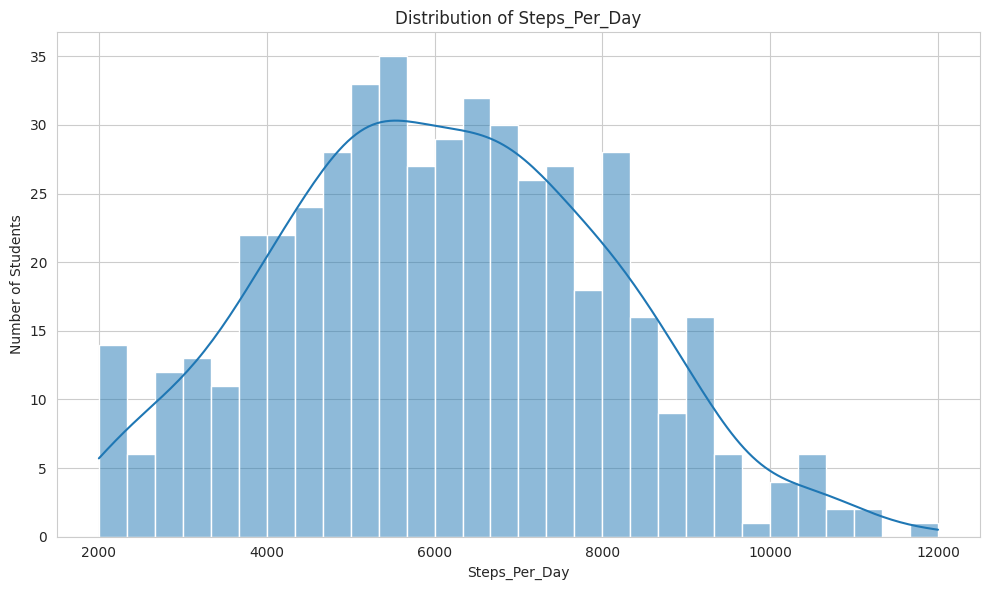

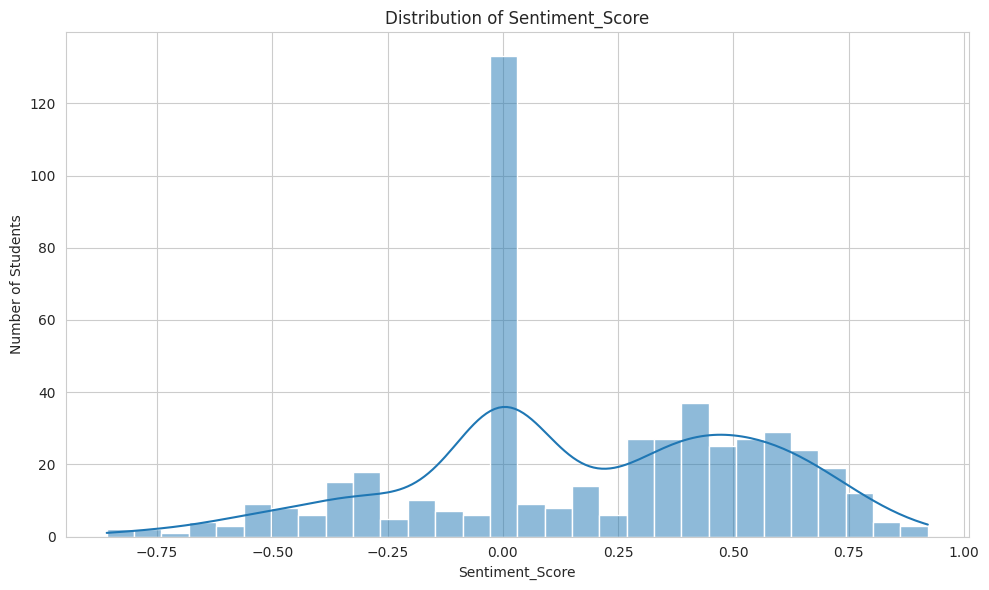

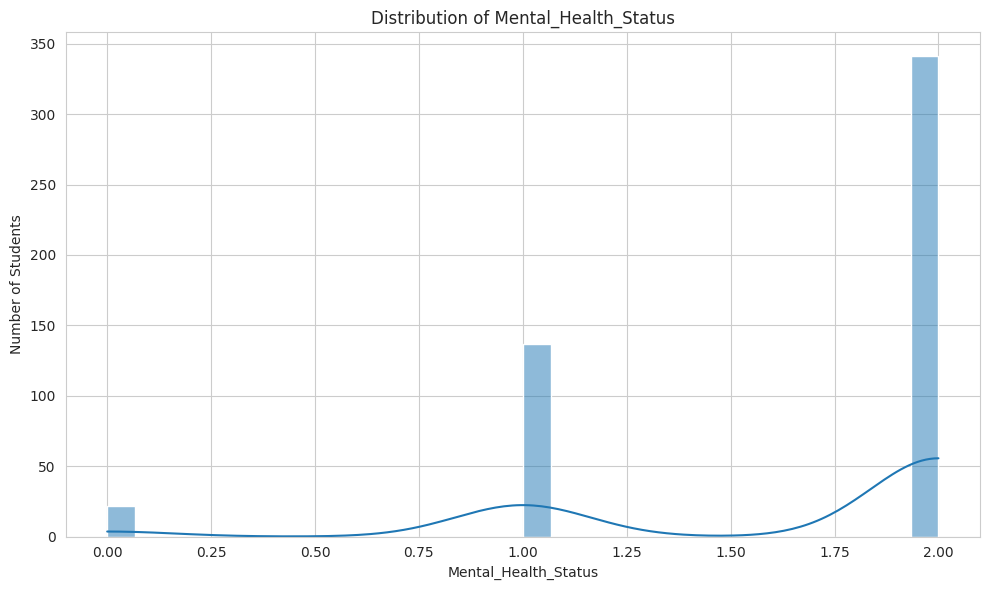

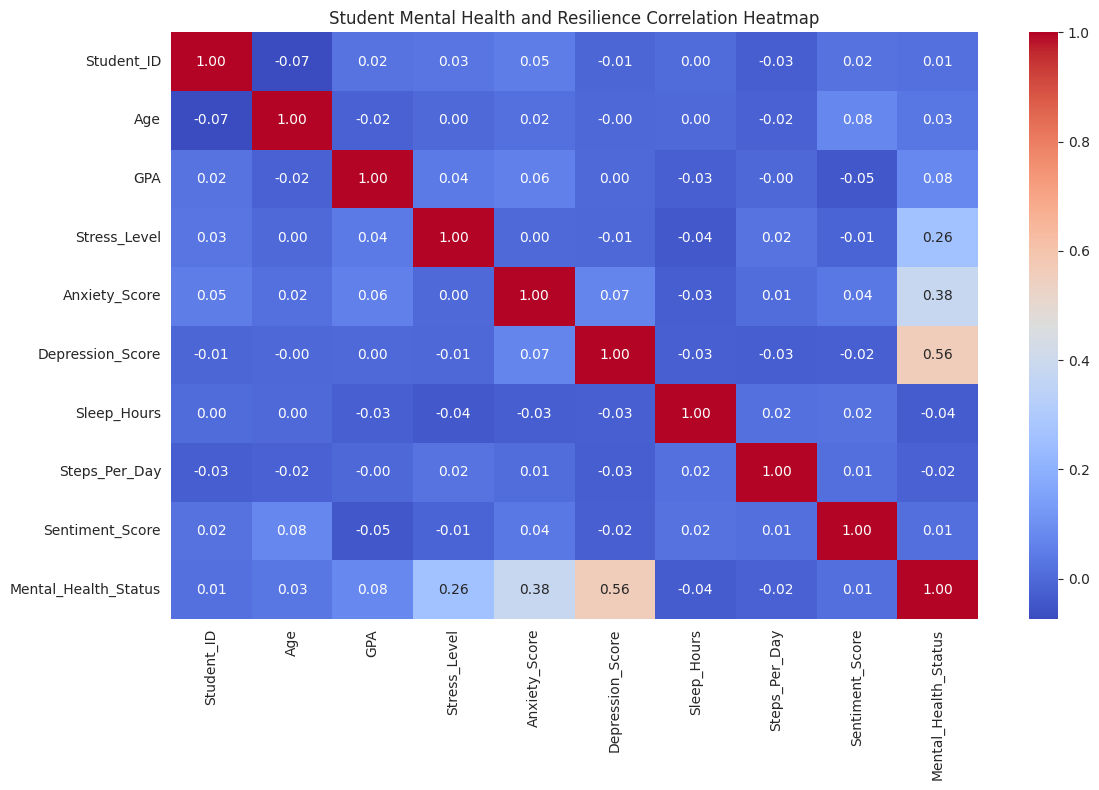

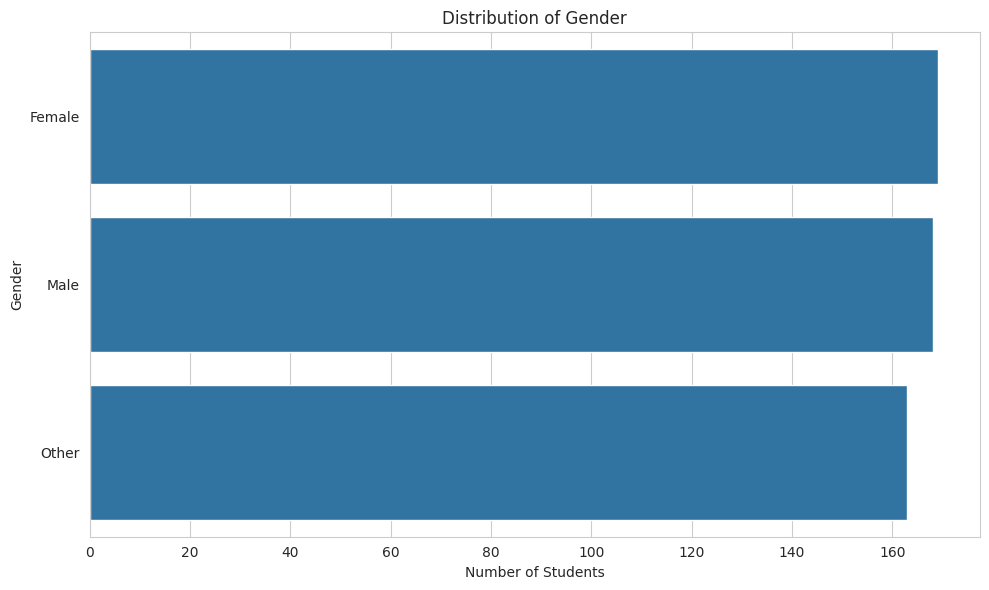

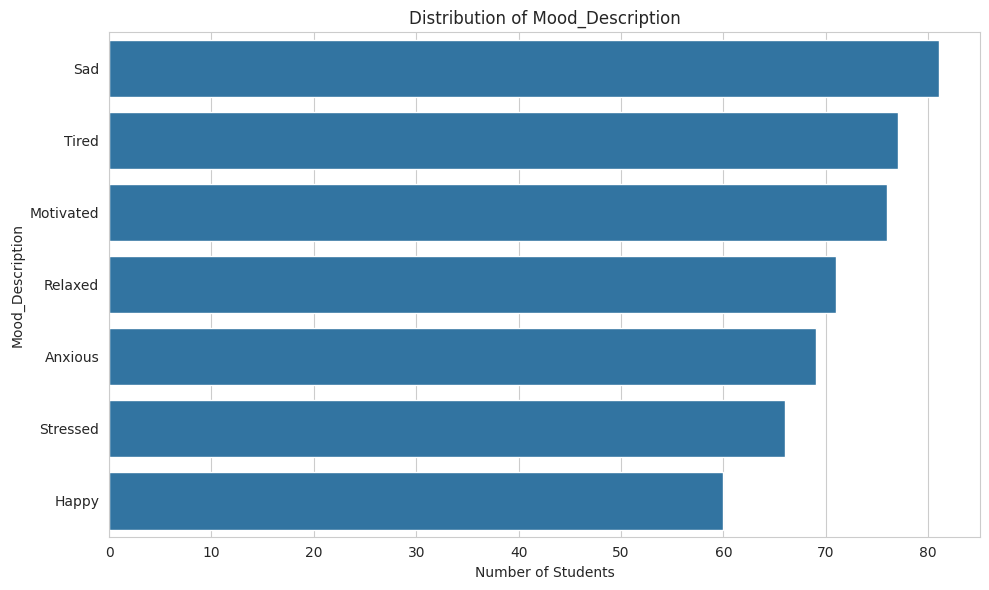

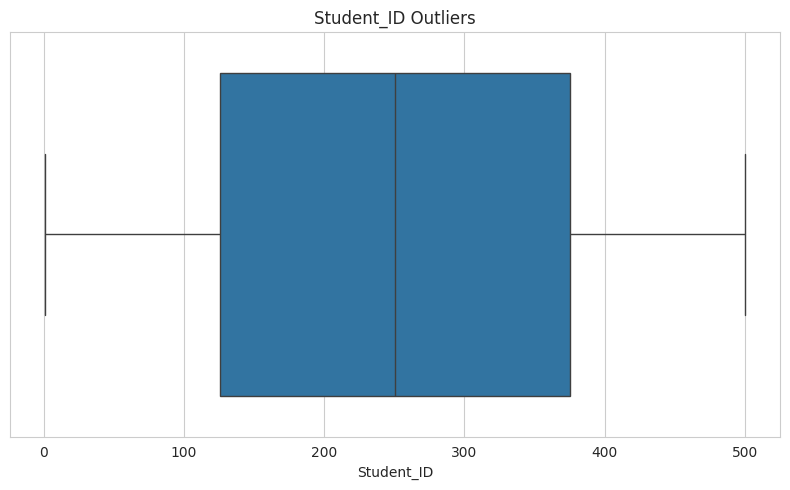

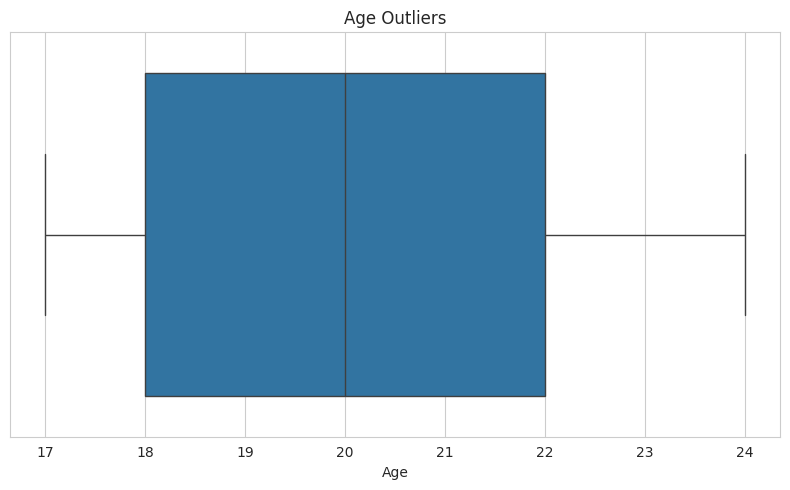

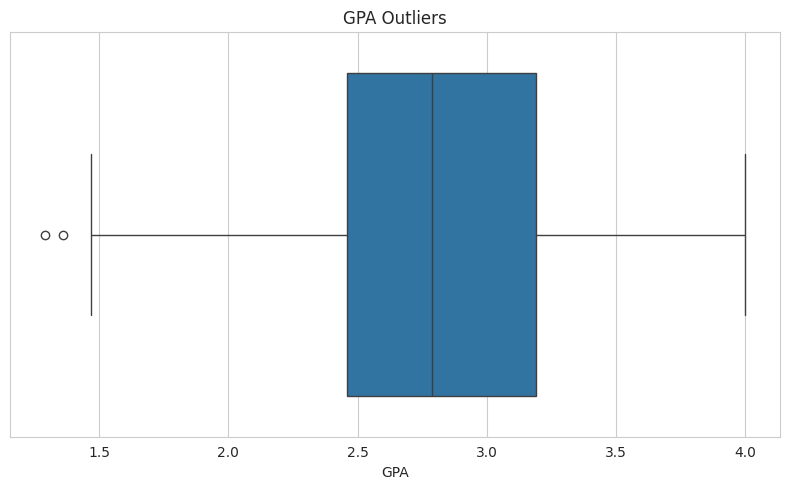

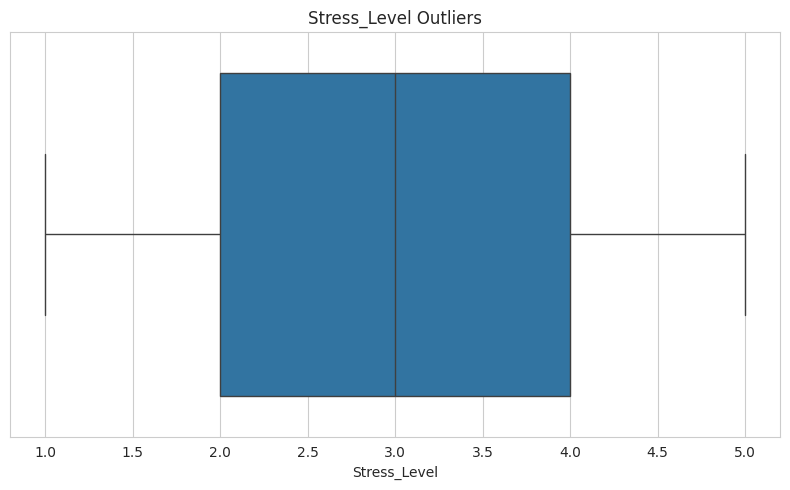

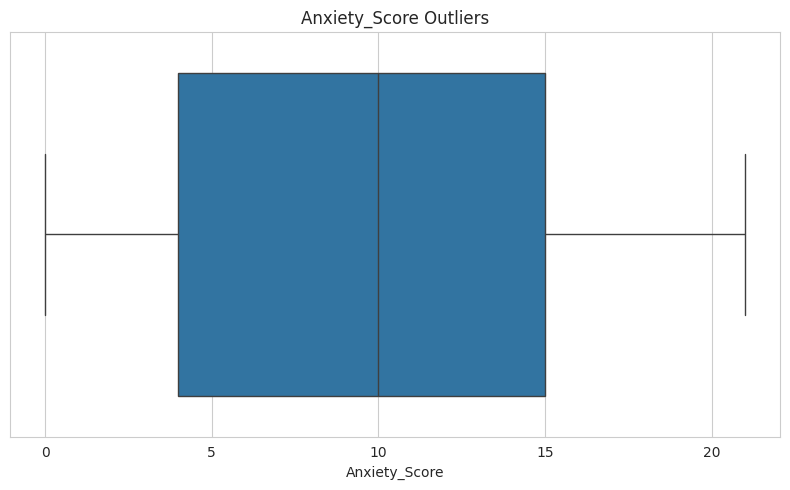

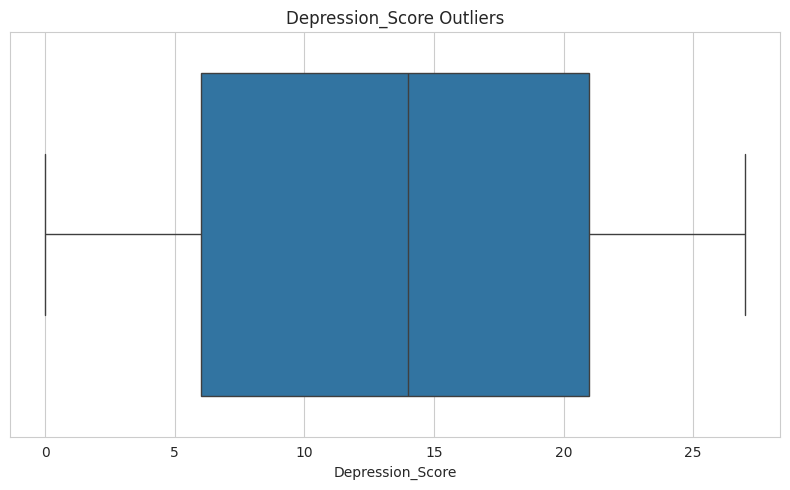

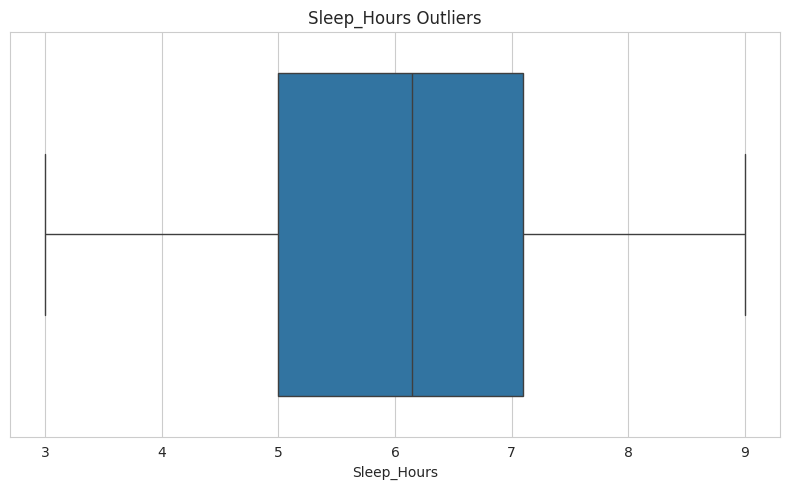

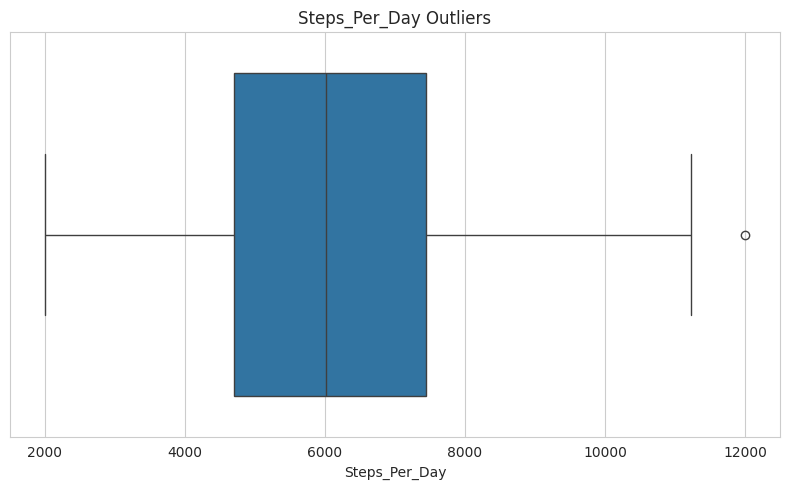

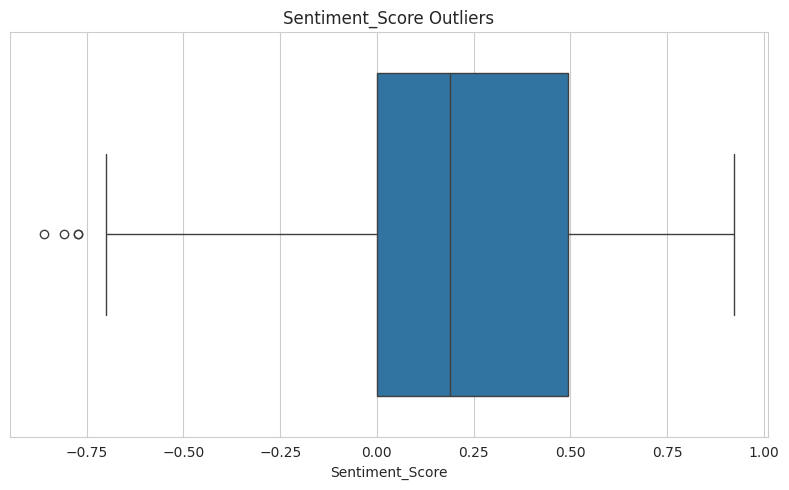

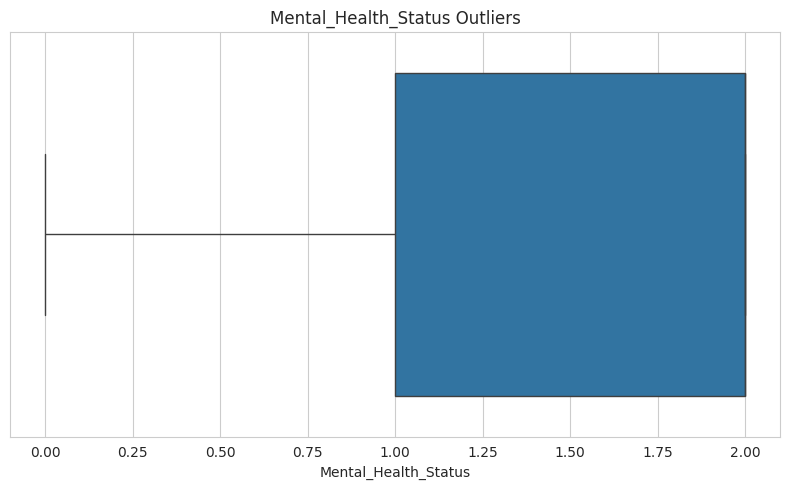

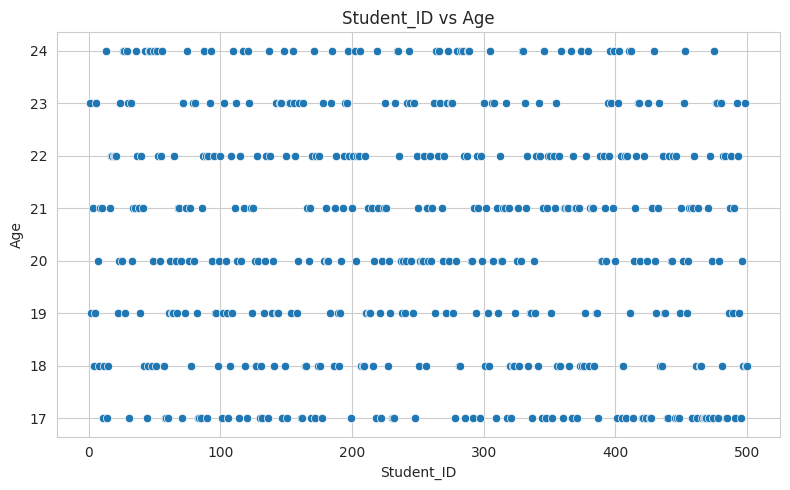

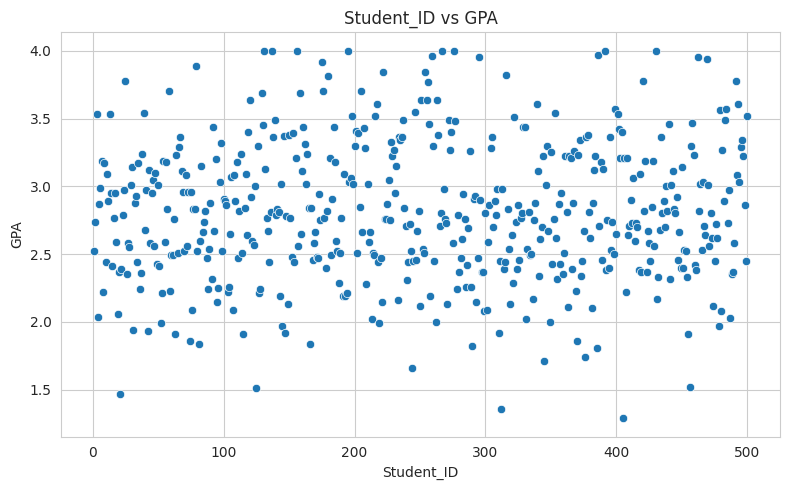

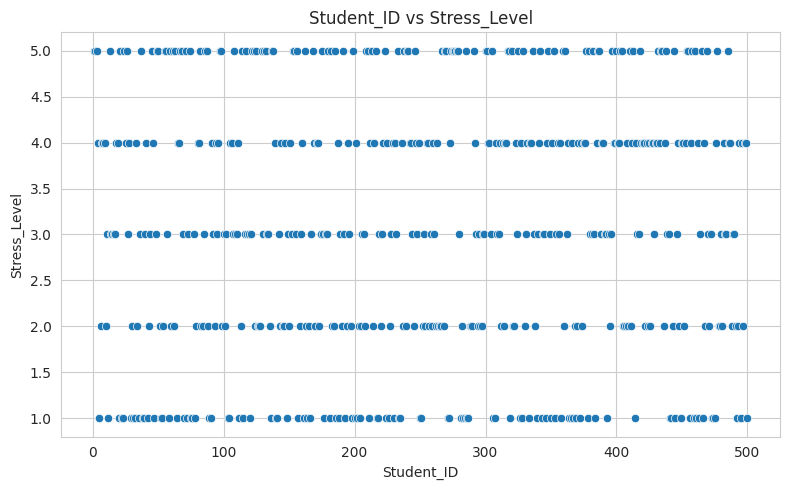

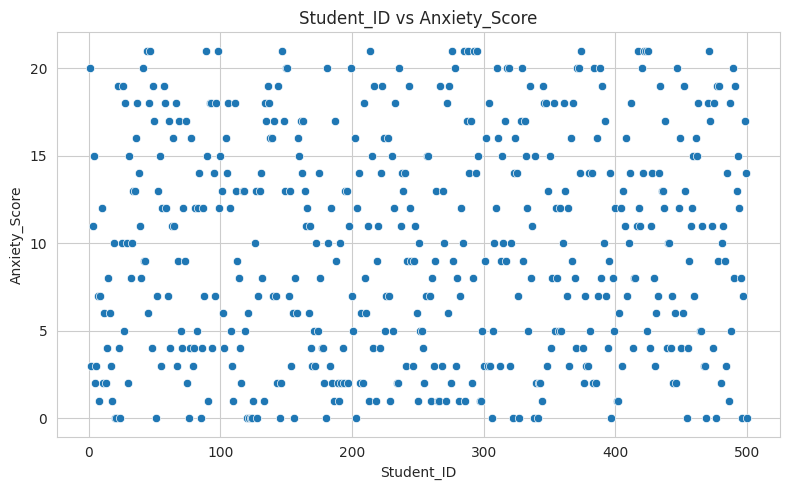

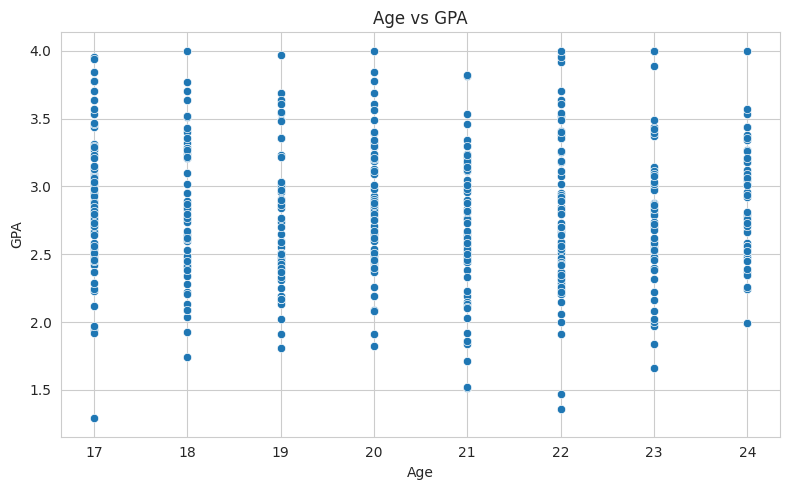

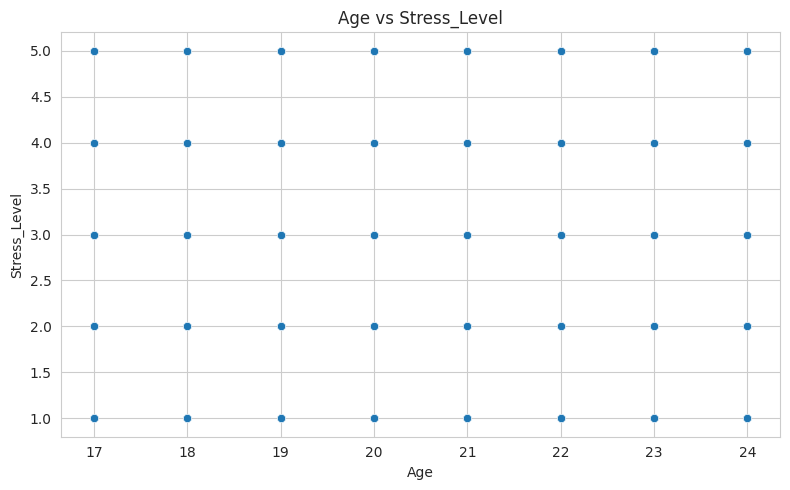

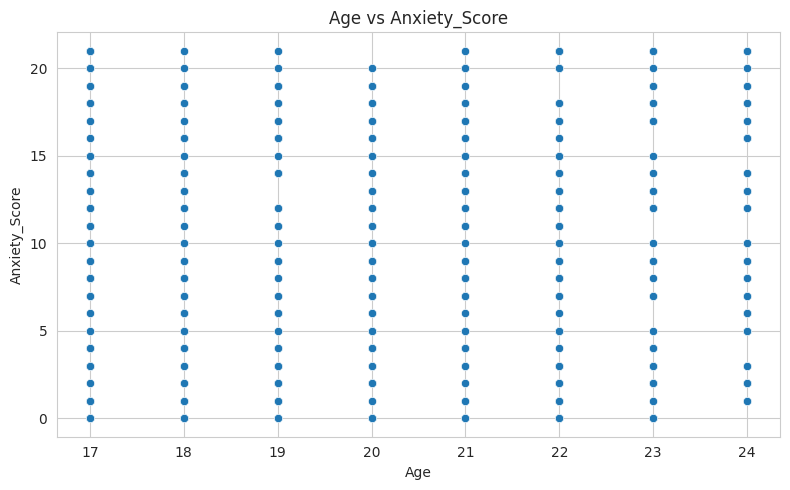

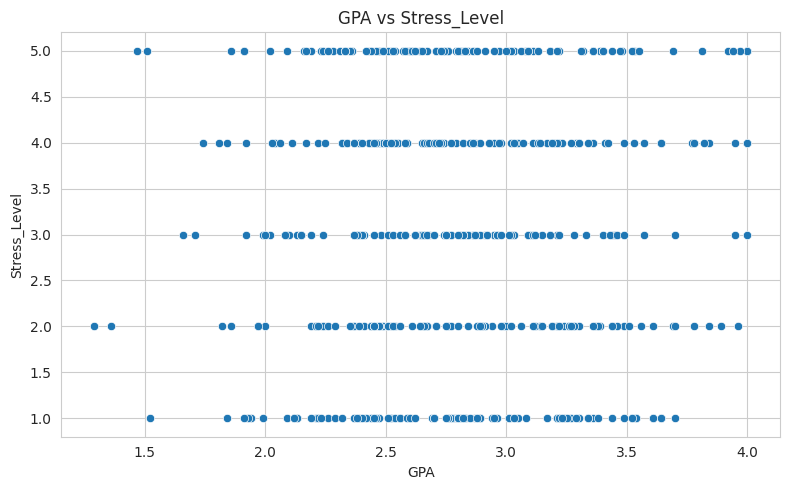

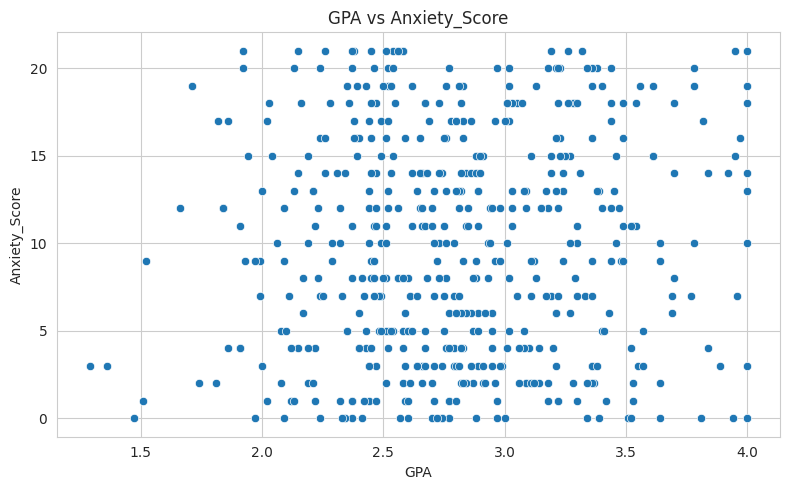

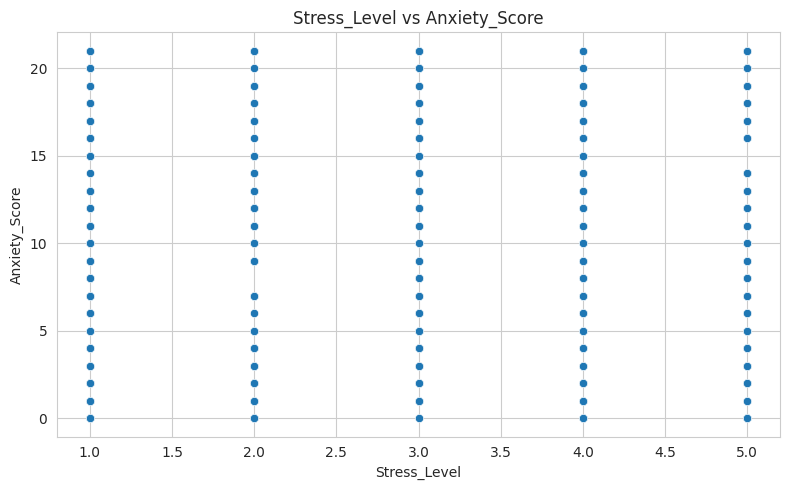


================ AVERAGE VALUES BY Gender ================
        Student_ID        Age       GPA  Stress_Level  Anxiety_Score  \
Gender                                                                 
Female  269.940828  20.266272  2.755385      3.177515       9.775148   
Other   247.177914  20.257669  2.841595      2.895706       9.466258   
Male    234.166667  20.571429  2.837083      3.107143      10.184524   

        Depression_Score  Sleep_Hours  Steps_Per_Day  Sentiment_Score  \
Gender                                                                  
Female         13.644970     6.197041    5959.248521         0.162850   
Other          13.809816     5.966258    6226.742331         0.164077   
Male           13.404762     6.026190    6020.428571         0.232309   

        Mental_Health_Status  
Gender                        
Female              1.650888  
Other               1.601227  
Male                1.660714  


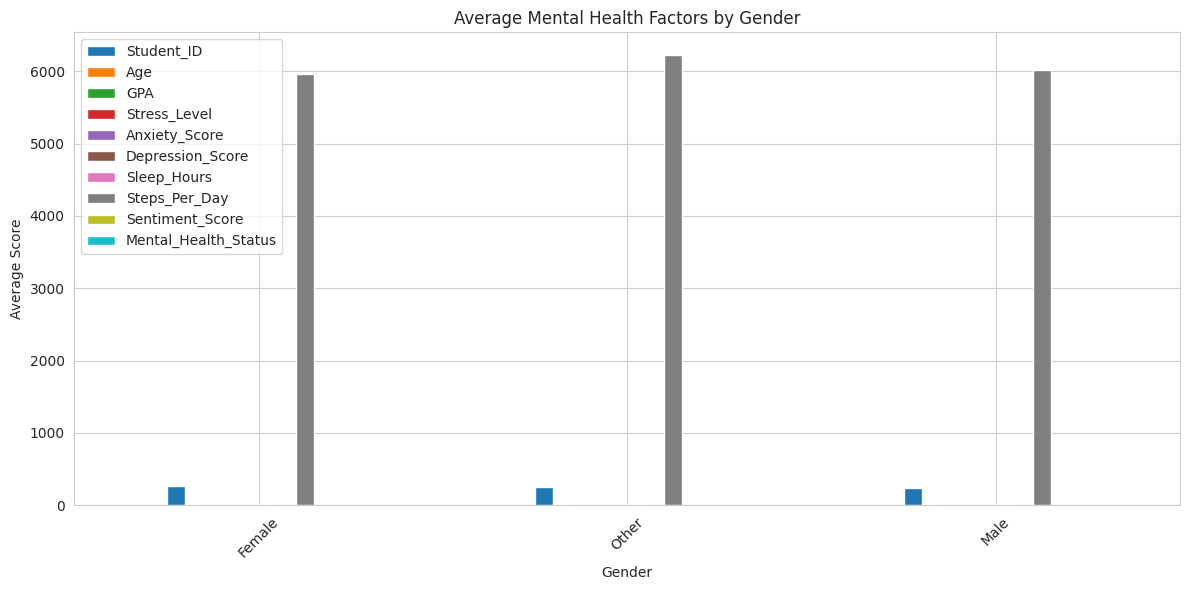


================ TOP 10 STUDENTS BY Student_ID ================
     Student_ID  Age  Gender   GPA  Stress_Level  Anxiety_Score  \
499         500   18   Other  3.52             1              0   
498         499   18  Female  2.45             4             14   
497         498   23   Other  2.86             4             17   
496         497   18  Female  3.22             2              7   
495         496   20   Other  3.34             4              0   
494         495   17  Female  3.29             1              8   
493         494   19   Other  3.03             4             12   
492         493   22    Male  3.61             2             15   
491         492   23  Female  3.08             1             13   
490         491   17  Female  3.78             2             19   

     Depression_Score                                  Daily_Reflections  \
499                 5  Get turn Congress list mouth city decision eas...   
498                 0       Care can now outs

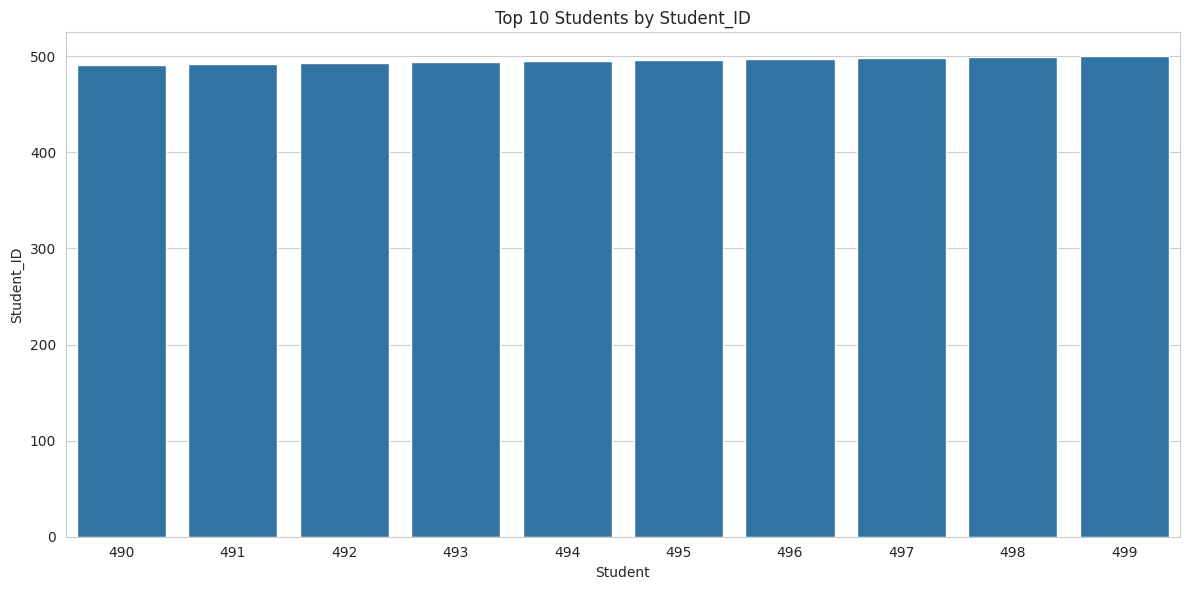

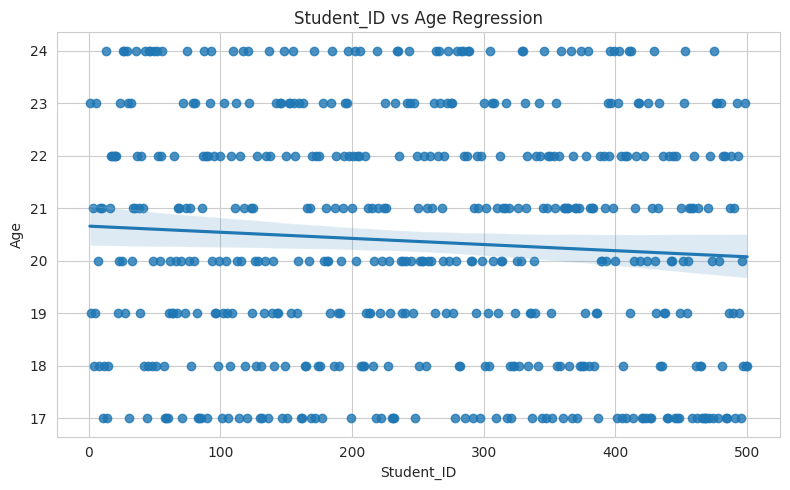

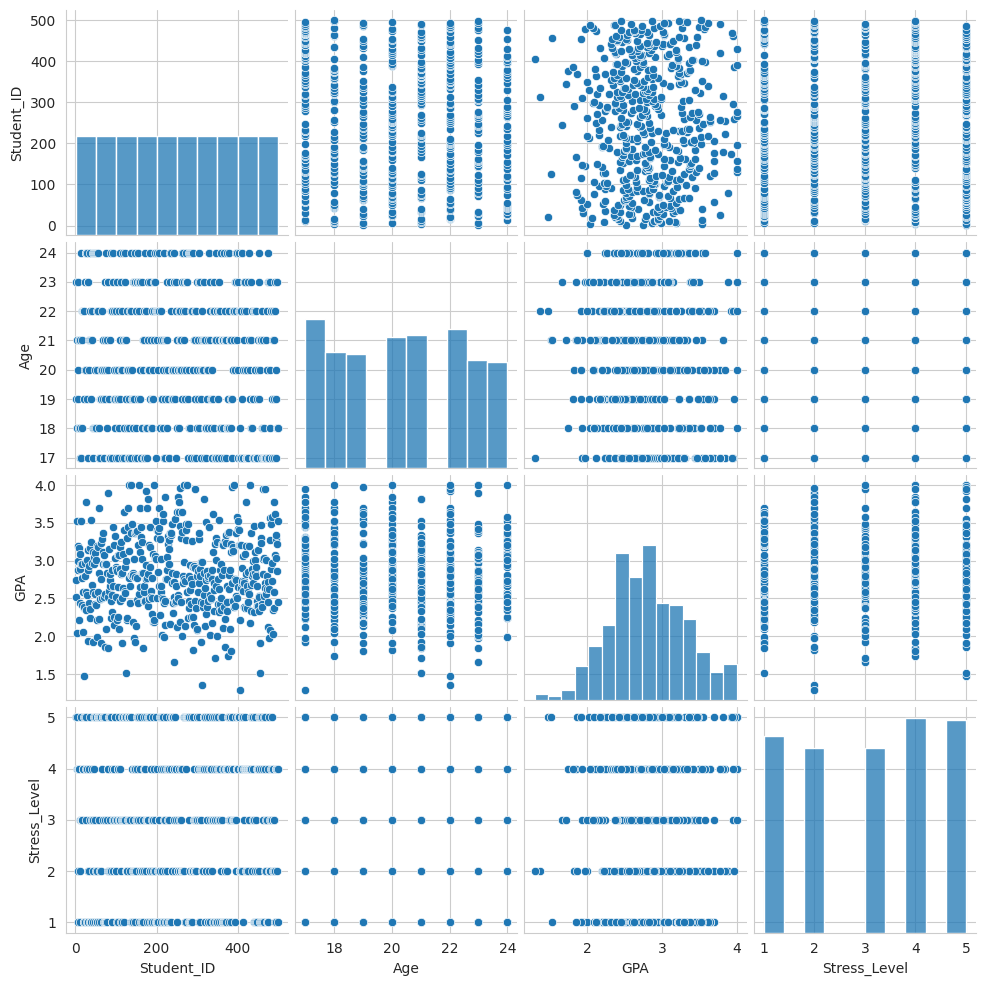

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

path = kagglehub.dataset_download(
    "ziya07/student-mental-health-and-resilience-dataset"
)

print("Path to dataset files:", path)

files = os.listdir(path)

csv_files = [
    file for file in files
    if file.lower().endswith(".csv")
]

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found in the downloaded dataset."
    )

csv_file = csv_files[0]

df = pd.read_csv(
    os.path.join(path, csv_file),
    engine="python",
    on_bad_lines="skip"
)

print("\nDataset Loaded Successfully!")
print("File:", csv_file)

print("\n================ FIRST 5 ROWS ================")
print(df.head())

print("\n================ LAST 5 ROWS ================")
print(df.tail())

print("\n================ DATASET SIZE ================")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n================ DATA INFORMATION ================")
df.info()

print("\n================ DESCRIPTIVE STATISTICS ================")
print(df.describe())

print("\n================ CATEGORICAL DATA ================")
print(df.describe(include="object"))

print("\n================ MISSING VALUES ================")
print(df.isnull().sum())

print("\n================ MISSING VALUE PERCENTAGE ================")
print(
    (df.isnull().sum() / len(df)) * 100
)

print("\n================ DUPLICATE RECORDS ================")
print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

print("\n================ UNIQUE VALUES ================")
print(df.nunique())

print("\n================ DATA TYPES ================")
print(df.dtypes)

num_cols = df.select_dtypes(
    include=np.number
).columns

cat_cols = df.select_dtypes(
    include="object"
).columns

print("\n================ NUMERICAL COLUMNS ================")
print(list(num_cols))

print("\n================ CATEGORICAL COLUMNS ================")
print(list(cat_cols))

for col in num_cols:
    plt.figure(figsize=(10, 6))

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True
    )

    plt.title(
        "Distribution of " + col
    )

    plt.xlabel(col)
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

if len(num_cols) > 0:

    corr = df[num_cols].corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title(
        "Student Mental Health and Resilience Correlation Heatmap"
    )

    plt.tight_layout()
    plt.show()

for col in cat_cols:

    if df[col].nunique() <= 15:

        plt.figure(figsize=(10, 6))

        value_counts = df[col].value_counts()

        sns.barplot(
            x=value_counts.values,
            y=value_counts.index
        )

        plt.title(
            "Distribution of " + col
        )

        plt.xlabel("Number of Students")
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()

for col in num_cols:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=df[col].dropna()
    )

    plt.title(
        col + " Outliers"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

if len(num_cols) >= 2:

    for i in range(min(len(num_cols), 5)):

        for j in range(i + 1, min(len(num_cols), 5)):

            plt.figure(figsize=(8, 5))

            sns.scatterplot(
                data=df,
                x=num_cols[i],
                y=num_cols[j]
            )

            plt.title(
                num_cols[i] + " vs " + num_cols[j]
            )

            plt.xlabel(num_cols[i])
            plt.ylabel(num_cols[j])

            plt.tight_layout()
            plt.show()

if len(cat_cols) > 0 and len(num_cols) > 0:

    group_col = cat_cols[0]

    if df[group_col].nunique() <= 15:

        grouped_data = (
            df.groupby(group_col)[list(num_cols)]
            .mean()
            .sort_values(
                by=num_cols[0],
                ascending=False
            )
        )

        print(
            "\n================ AVERAGE VALUES BY "
            + group_col
            + " ================"
        )

        print(grouped_data)

        grouped_data.plot(
            kind="bar",
            figsize=(12, 6)
        )

        plt.title(
            "Average Mental Health Factors by "
            + group_col
        )

        plt.xlabel(group_col)
        plt.ylabel("Average Score")

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

if len(num_cols) > 0:

    top_values = (
        df.sort_values(
            by=num_cols[0],
            ascending=False
        )
        .head(10)
    )

    print(
        "\n================ TOP 10 STUDENTS BY "
        + num_cols[0]
        + " ================"
    )

    print(top_values)

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=top_values,
        x=top_values.index,
        y=num_cols[0]
    )

    plt.title(
        "Top 10 Students by " + num_cols[0]
    )

    plt.xlabel("Student")
    plt.ylabel(num_cols[0])

    plt.tight_layout()
    plt.show()

if len(num_cols) >= 2:

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=df,
        x=num_cols[0],
        y=num_cols[1]
    )

    plt.title(
        num_cols[0]
        + " vs "
        + num_cols[1]
        + " Regression"
    )

    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])

    plt.tight_layout()
    plt.show()

if len(num_cols) >= 3:

    selected_cols = list(num_cols[:4])

    sns.pairplot(
        df[selected_cols].dropna()
    )

    plt.show()



In [2]:
print(
    "\n======================================================"
)

print(
    "       STUDENT MENTAL HEALTH AND RESILIENCE EDA"
)

print(
    "======================================================"
)

print("\nDataset Information:")

print(
    "Total Rows:",
    df.shape[0]
)

print(
    "Total Columns:",
    df.shape[1]
)

print(
    "\nNumerical Variables:",
    len(num_cols)
)

print(
    "Categorical Variables:",
    len(cat_cols)
)

for col in num_cols:

    print(
        "\n" + col + ":"
    )

    print(
        "Mean:",
        round(df[col].mean(), 2)
    )

    print(
        "Median:",
        round(df[col].median(), 2)
    )

    print(
        "Minimum:",
        round(df[col].min(), 2)
    )

    print(
        "Maximum:",
        round(df[col].max(), 2)
    )

    print(
        "Standard Deviation:",
        round(df[col].std(), 2)
    )

print(
    "\nDuplicate Rows:",
    df.duplicated().sum()
)

print(
    "\nEDA completed successfully!"
)



       STUDENT MENTAL HEALTH AND RESILIENCE EDA

Dataset Information:
Total Rows: 500
Total Columns: 13

Numerical Variables: 10
Categorical Variables: 3

Student_ID:
Mean: 250.5
Median: 250.5
Minimum: 1
Maximum: 500
Standard Deviation: 144.48

Age:
Mean: 20.37
Median: 20.0
Minimum: 17
Maximum: 24
Standard Deviation: 2.27

GPA:
Mean: 2.81
Median: 2.79
Minimum: 1.29
Maximum: 4.0
Standard Deviation: 0.51

Stress_Level:
Mean: 3.06
Median: 3.0
Minimum: 1
Maximum: 5
Standard Deviation: 1.43

Anxiety_Score:
Mean: 9.81
Median: 10.0
Minimum: 0
Maximum: 21
Standard Deviation: 6.35

Depression_Score:
Mean: 13.62
Median: 14.0
Minimum: 0
Maximum: 27
Standard Deviation: 8.32

Sleep_Hours:
Mean: 6.06
Median: 6.15
Minimum: 3.0
Maximum: 9.0
Standard Deviation: 1.52

Steps_Per_Day:
Mean: 6067.01
Median: 6019.0
Minimum: 2000
Maximum: 12000
Standard Deviation: 1974.22

Sentiment_Score:
Mean: 0.19
Median: 0.19
Minimum: -0.86
Maximum: 0.92
Standard Deviation: 0.37

Mental_Health_Status:
Mean: 1.64
Median: